In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


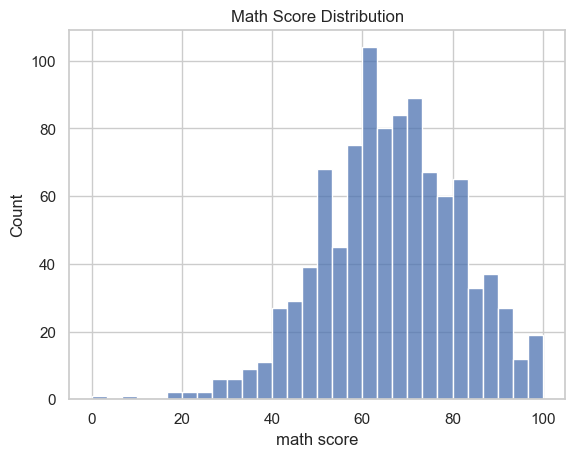

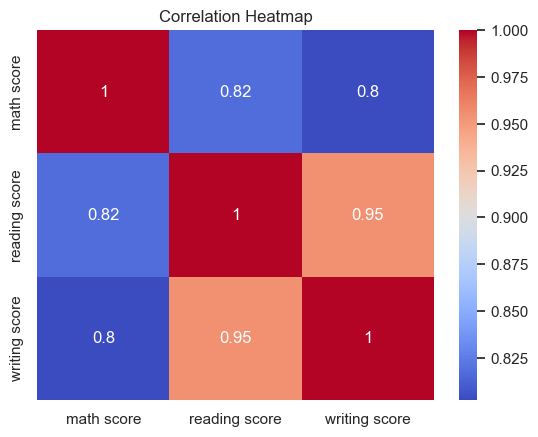

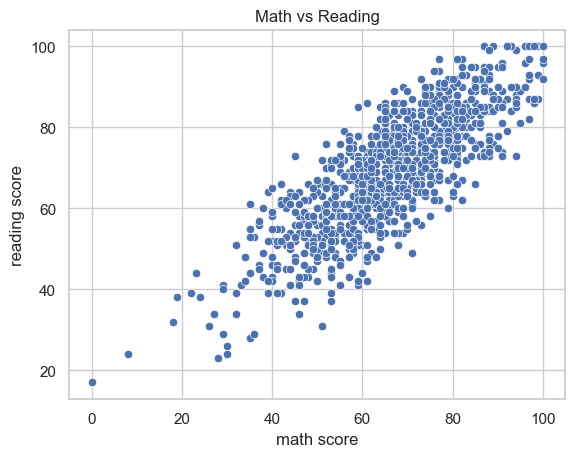

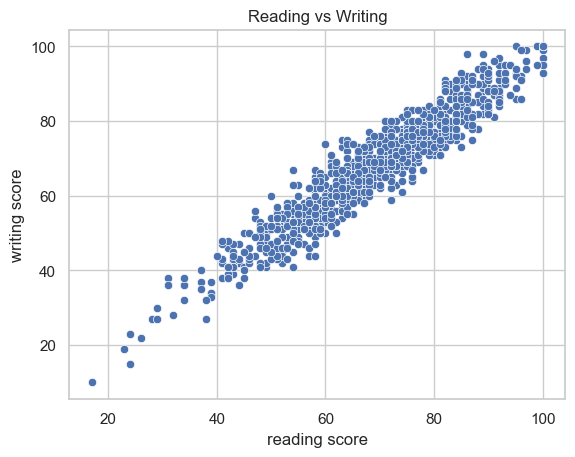

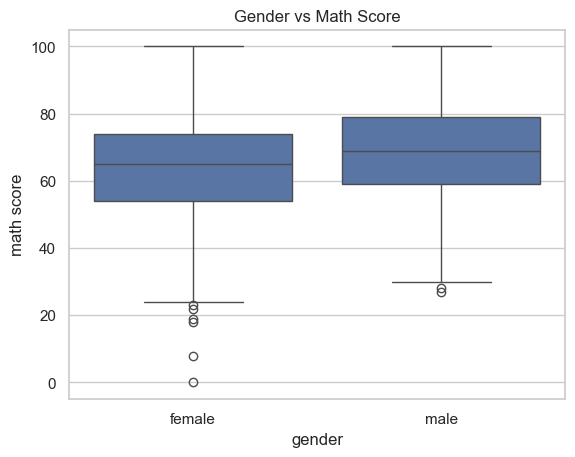

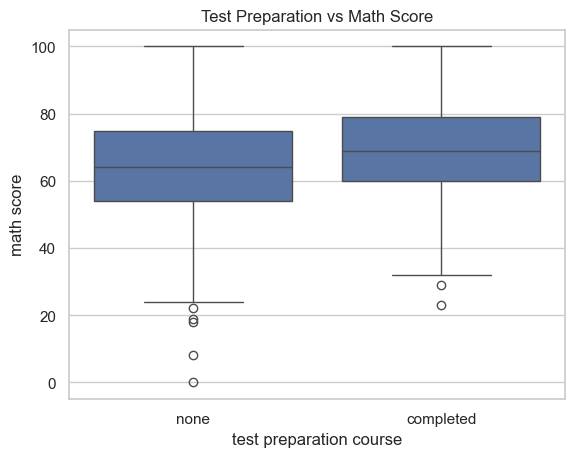

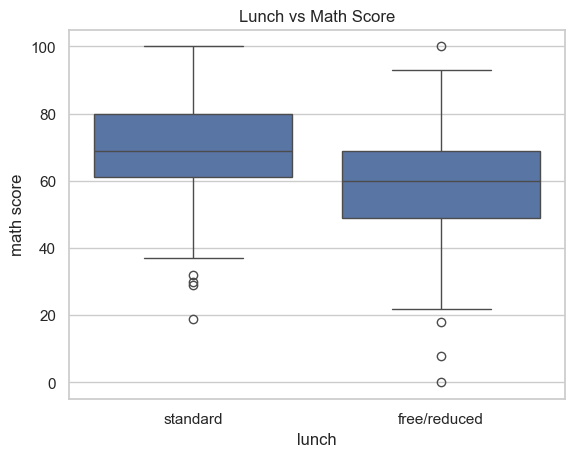


Average Scores by Gender:
         math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203

Average Scores by Test Preparation:
                          math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673

Top 5 Students (Math Score):
      gender race/ethnicity parental level of education         lunch  \
451  female        group E                some college      standard   
458  female        group E           bachelor's degree      standard   
962  female        group E          associate's degree      standard   
149    male        group E          associate's degree  free/reduced   
623    male        group A                some college      standard   

    test p

In [11]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ================== LOAD DATA ==================
df = pd.read_csv(r"C:\Users\VARSHITHA\Downloads\StudentsPerformance.csv")  # change path

# ================== CLEAN COLUMN NAMES ==================
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# ================== BASIC INFO ==================
print("\nMissing Values:\n", df.isnull().sum())

# ================== REMOVE DUPLICATES ==================
df.drop_duplicates(inplace=True)

# ================== UNIVARIATE ANALYSIS ==================
sns.histplot(df['math score'], bins=30)
plt.title("Math Score Distribution")
plt.show()

# ================== CORRELATION HEATMAP ==================
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ================== SCATTER PLOTS ==================
sns.scatterplot(x='math score', y='reading score', data=df)
plt.title("Math vs Reading")
plt.show()

sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title("Reading vs Writing")
plt.show()

# ================== CATEGORICAL ANALYSIS ==================
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Gender vs Math Score")
plt.show()

sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title("Test Preparation vs Math Score")
plt.show()

sns.boxplot(x='lunch', y='math score', data=df)
plt.title("Lunch vs Math Score")
plt.show()

# ================== AVERAGE SCORES ==================
print("\nAverage Scores by Gender:\n", df.groupby('gender')[['math score','reading score','writing score']].mean())

print("\nAverage Scores by Test Preparation:\n", df.groupby('test preparation course')[['math score','reading score','writing score']].mean())

# ================== TOP PERFORMERS ==================
top_students = df.sort_values(by='math score', ascending=False).head(5)
print("\nTop 5 Students (Math Score):\n", top_students)

# ================== SIMPLE MODEL ==================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['reading score']]
y = df['writing score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Score (Reading → Writing):", model.score(X_test, y_test))

print("\n✅ EDA Completed Successfully!")